# Taller 2 — Contenido de agua en el suelo (SOLUCIÓN)

**Asignatura:** TAG2027 — Relación Suelo Agua Planta | UDLA  
**Unidad:** 2 — El agua en el suelo (completo)  
**Duración:** 3 horas  
**Ejercicio vinculado:** Ejercicio 1  
**RAA:** RAA2, RAA3, RAA4

> **Versión con soluciones para el docente.** Las celdas `# TODO` están resueltas y se agregan respuestas sugeridas a las preguntas de interpretación.

---

## Objetivos

Al finalizar este taller serás capaz de:
1. Convertir contenido gravimétrico (θg) a volumétrico (θv)
2. Construir e interpretar una curva característica de retención de agua
3. Identificar CC y PMP y calcular ADT y AFA
4. Procesar datos de campo para caracterizar variabilidad espacial de humedad
5. Calcular lámina de agua aprovechable en un perfil completo

---

## Instrucciones

1. Ejecuta cada celda en orden (Shift + Enter)
2. Completa las celdas marcadas con `# TODO`
3. Entrega el notebook con todas las celdas ejecutadas

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/frzambra/RSPA-TAG-UDLA/blob/main/labs/taller-02/taller-02_solucion.ipynb)

In [1]:
# ========================================
# Celda de setup — Ejecutar primero
# ========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✓ Setup completo.')

✓ Setup completo.


---
## Parte 1: Conversión θg → θv (30 min)

Recordemos la fórmula:

$$\theta_v = \theta_g \times \frac{D_a}{\rho_{agua}}$$

Con $\rho_{agua} \approx 1.0$ g/cm³, simplificamos: $\theta_v \approx \theta_g \times D_a$

### Datos del ejercicio

Se muestrearon 4 suelos de distinta textura. Para cada uno se determinó θg por el método gravimétrico y Da por el método del cilindro:

In [2]:
# Datos de suelos contrastantes
suelos = pd.DataFrame({
    'Suelo': ['Arenoso', 'Franco-arenoso', 'Franco', 'Arcilloso'],
    'Theta_g_gg': [0.12, 0.20, 0.28, 0.38],  # g/g
    'Da_g_cm3': [1.60, 1.45, 1.32, 1.10]      # g/cm³
})
print('Datos de entrada:')
suelos

Datos de entrada:


,Suelo,Theta_g_gg,Da_g_cm3
0,Arenoso,0.12,1.60
1,Franco-arenoso,0.20,1.45
2,Franco,0.28,1.32
3,Arcilloso,0.38,1.10


In [3]:
# SOLUCIÓN — Calcular θv (cm³/cm³) para cada suelo
# θv = θg × Da / ρ_agua  (ρ_agua = 1.0 g/cm³)

rho_agua = 1.0  # g/cm³
suelos['Theta_v_cm3cm3'] = suelos['Theta_g_gg'] * suelos['Da_g_cm3'] / rho_agua

# Mostrar resultados
suelos[['Suelo', 'Theta_g_gg', 'Da_g_cm3', 'Theta_v_cm3cm3']].round(3)

,Suelo,Theta_g_gg,Da_g_cm3,Theta_v_cm3cm3
0,Arenoso,0.12,1.60,0.192
1,Franco-arenoso,0.20,1.45,0.290
2,Franco,0.28,1.32,0.370
3,Arcilloso,0.38,1.10,0.418


In [4]:
# Celda de validación
if 'Theta_v_cm3cm3' in suelos.columns:
    tv_ok = np.allclose(suelos['Theta_v_cm3cm3'], [0.192, 0.290, 0.370, 0.418], atol=0.01)
    print('✓ θv correcto' if tv_ok else '⚠ Revisa los cálculos de θv')
else:
    print('⚠ Calcula Theta_v_cm3cm3 primero')

✓ θv correcto


### Pregunta de interpretación

Observa los resultados. ¿Qué suelo tiene más agua en términos **volumétricos**? ¿Es el mismo que tenía más agua en términos gravimétricos? ¿Por qué? Responde en una celda de texto.

### Respuesta sugerida (θg vs θv)

| Suelo | θg (g/g) | Da (g/cm³) | θv (cm³/cm³) |
|-------|---------|-----------|--------------|
| Arenoso | 0.12 | 1.60 | 0.192 |
| Franco-arenoso | 0.20 | 1.45 | 0.290 |
| Franco | 0.28 | 1.32 | 0.370 |
| Arcilloso | 0.38 | 1.10 | 0.418 |

El suelo **arcilloso** tiene el mayor contenido de agua tanto en términos gravimétricos como volumétricos, así que el orden de los suelos no cambia. Lo que sí cambia es la **distancia** entre ellos: θg del arcilloso es 3,2 veces la del arenoso, pero θv es solo 2,2 veces.

Esto ocurre porque θv = θg × Da. El arenoso tiene la Da más alta (1,60 g/cm³), de modo que cada gramo de suelo ocupa menos volumen y "pesa más" al pasar a base volumétrica; el arcilloso, con Da baja (1,10 g/cm³), se ve penalizado. Por eso θv es la medida útil para riego: expresa el agua por unidad de **volumen** de suelo explorado por las raíces y se convierte directamente en lámina (mm), mientras que θg depende de cuánto pesa el suelo.

---
## Parte 2: Curva característica de retención de agua (45 min)

La **curva característica** relaciona el contenido volumétrico de agua (θv) con el potencial mátrico (Ψm).

Vamos a trabajar con datos de 3 suelos contrastantes: arenoso, franco y arcilloso.

### Datos de curvas de retención

Para cada suelo tenemos θv medido a distintos Ψm (kPa):

In [5]:
# Curvas de retención para 3 suelos
# Ψm en kPa (valores absolutos), θv en cm³/cm³

psi_kpa = np.array([0, 5, 10, 33, 50, 100, 300, 500, 1000, 1500])

curvas = pd.DataFrame({
    'Psi_kPa': psi_kpa,
    'Arenoso':     [0.42, 0.28, 0.18, 0.12, 0.09, 0.07, 0.05, 0.04, 0.035, 0.03],
    'Franco':      [0.48, 0.42, 0.38, 0.30, 0.26, 0.22, 0.17, 0.14, 0.12, 0.11],
    'Arcilloso':   [0.55, 0.52, 0.49, 0.40, 0.36, 0.32, 0.26, 0.24, 0.22, 0.21]
})

print('Curvas de retención (θv a distintos Ψm):')
curvas

Curvas de retención (θv a distintos Ψm):


,Psi_kPa,Arenoso,Franco,Arcilloso
0,0,0.420,0.48,0.55
1,5,0.280,0.42,0.52
2,10,0.180,0.38,0.49
3,33,0.120,0.30,0.40
4,50,0.090,0.26,0.36
5,100,0.070,0.22,0.32
6,300,0.050,0.17,0.26
7,500,0.040,0.14,0.24
8,1000,0.035,0.12,0.22
9,1500,0.030,0.11,0.21


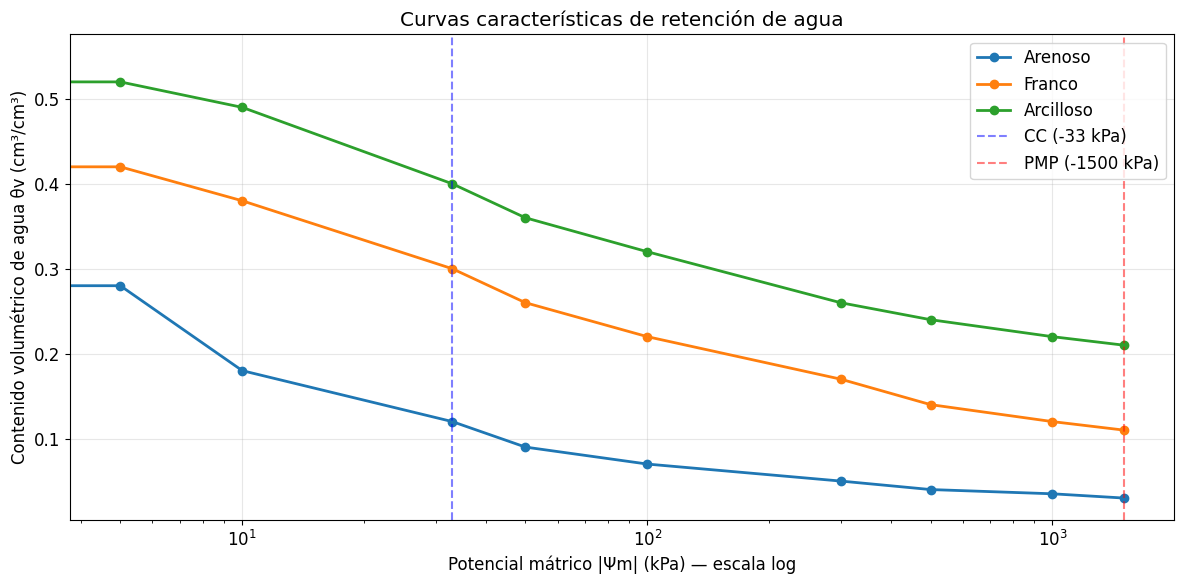

In [6]:
# Graficar las curvas de retención
# Eje X: Ψm en escala logarítmica
# Eje Y: θv

fig, ax = plt.subplots(figsize=(12, 6))

for suelo in ['Arenoso', 'Franco', 'Arcilloso']:
    ax.semilogx(curvas['Psi_kPa'], curvas[suelo], 'o-', linewidth=2, markersize=6, label=suelo)

# Líneas de referencia: CC y PMP
ax.axvline(x=33, color='blue', linestyle='--', alpha=0.5, label='CC (-33 kPa)')
ax.axvline(x=1500, color='red', linestyle='--', alpha=0.5, label='PMP (-1500 kPa)')

ax.set_xlabel('Potencial mátrico |Ψm| (kPa) — escala log')
ax.set_ylabel('Contenido volumétrico de agua θv (cm³/cm³)')
ax.set_title('Curvas características de retención de agua')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Ejercicio 2.2: Identificar CC y PMP

De la tabla y gráfico anteriores:
- **CC** = θv a Ψm = 33 kPa
- **PMP** = θv a Ψm = 1500 kPa

In [7]:
# SOLUCIÓN — Extraer CC y PMP de la tabla para cada suelo

fila_cc = curvas[curvas['Psi_kPa'] == 33]
fila_pmp = curvas[curvas['Psi_kPa'] == 1500]

cc_arenoso = fila_cc['Arenoso'].values[0]
pmp_arenoso = fila_pmp['Arenoso'].values[0]

cc_franco = fila_cc['Franco'].values[0]
pmp_franco = fila_pmp['Franco'].values[0]

cc_arcilloso = fila_cc['Arcilloso'].values[0]
pmp_arcilloso = fila_pmp['Arcilloso'].values[0]

# Crear tabla resumen
resumen_cc_pmp = pd.DataFrame({
    'Suelo': ['Arenoso', 'Franco', 'Arcilloso'],
    'CC': [cc_arenoso, cc_franco, cc_arcilloso],
    'PMP': [pmp_arenoso, pmp_franco, pmp_arcilloso]
})
print('Capacidad de Campo (CC) y Punto de Marchitez Permanente (PMP):')
resumen_cc_pmp

Capacidad de Campo (CC) y Punto de Marchitez Permanente (PMP):


,Suelo,CC,PMP
0,Arenoso,0.12,0.03
1,Franco,0.30,0.11
2,Arcilloso,0.40,0.21


In [8]:
# Celda de validación
# Valores esperados:
# Arenoso:   CC=0.12, PMP=0.03
# Franco:    CC=0.30, PMP=0.11
# Arcilloso: CC=0.40, PMP=0.21

cc_esperado = {'Arenoso': 0.12, 'Franco': 0.30, 'Arcilloso': 0.40}
pmp_esperado = {'Arenoso': 0.03, 'Franco': 0.11, 'Arcilloso': 0.21}

if 'resumen_cc_pmp' in dir():
    ok = True
    for s in ['Arenoso', 'Franco', 'Arcilloso']:
        fila = resumen_cc_pmp[resumen_cc_pmp['Suelo']==s]
        if not np.isclose(fila['CC'].values[0], cc_esperado[s], atol=0.01):
            print(f'⚠ CC de {s} incorrecta')
            ok = False
        if not np.isclose(fila['PMP'].values[0], pmp_esperado[s], atol=0.01):
            print(f'⚠ PMP de {s} incorrecto')
            ok = False
    print('✓ CC y PMP correctos' if ok else '⚠ Revisa los valores')
else:
    print('⚠ Crea la tabla resumen_cc_pmp primero')

✓ CC y PMP correctos


---
## Parte 3: Cálculo de ADT y AFA (30 min)

### Fórmulas

$$ADT = CC - PMP \quad [\text{cm}^3/\text{cm}^3]$$

$$AFA = ADT \times p$$

Donde $p$ = fracción de agotamiento permisible.

In [9]:
# SOLUCIÓN — Calcular ADT para cada suelo

adt_arenoso = cc_arenoso - pmp_arenoso
adt_franco = cc_franco - pmp_franco
adt_arcilloso = cc_arcilloso - pmp_arcilloso

# También se agrega a la tabla resumen
resumen_cc_pmp['ADT'] = resumen_cc_pmp['CC'] - resumen_cc_pmp['PMP']

print('Agua Disponible Total (ADT):')
for suelo, adt in [('Arenoso', adt_arenoso), ('Franco', adt_franco), ('Arcilloso', adt_arcilloso)]:
    print(f'  {suelo}: {adt:.3f} cm³/cm³')

Agua Disponible Total (ADT):
  Arenoso: 0.090 cm³/cm³
  Franco: 0.190 cm³/cm³
  Arcilloso: 0.190 cm³/cm³


In [10]:
# SOLUCIÓN — Calcular AFA para distintos cultivos

# Fracciones de agotamiento permisibles (p)
cultivos = {
    'Lechuga': 0.30,
    'Maíz': 0.50,
    'Vid': 0.45,
    'Alfalfa': 0.60
}

# AFA = ADT × p para cada combinación suelo-cultivo
# Filas: suelos | Columnas: cultivos
tabla_afa = pd.DataFrame(
    {cultivo: resumen_cc_pmp['ADT'].values * p for cultivo, p in cultivos.items()},
    index=resumen_cc_pmp['Suelo']
)
tabla_afa.insert(0, 'ADT', resumen_cc_pmp['ADT'].values)

# Mostrar tabla
print('Agua Fácilmente Aprovechable (AFA, cm³/cm³):')
tabla_afa.round(3)

Agua Fácilmente Aprovechable (AFA, cm³/cm³):


,ADT,Lechuga,Maíz,Vid,Alfalfa
Suelo,,,,,
Arenoso,0.09,0.027,0.045,0.040,0.054
Franco,0.19,0.057,0.095,0.086,0.114
Arcilloso,0.19,0.057,0.095,0.086,0.114


### Pregunta de interpretación

¿En qué suelo necesita regarse con más frecuencia un cultivo de maíz? ¿Por qué? ¿Qué implicancias prácticas tiene esto?

### Respuesta sugerida (frecuencia de riego)

Para maíz (p = 0,50) la AFA es 0,045 cm³/cm³ en el suelo **arenoso**, 0,095 en el franco y 0,095 en el arcilloso. El suelo **arenoso** es el que debe regarse con más frecuencia: su reserva fácilmente aprovechable es menos de la mitad de la de los otros dos, así que el cultivo la agota en menos días con la misma ETc.

La razón está en la curva de retención: la arena tiene poros grandes que drenan casi todo el agua a potenciales bajos (entre 0 y −33 kPa pasa de 0,42 a 0,12 cm³/cm³), y retiene poca agua entre CC y PMP.

Implicancias prácticas:
- En suelo arenoso conviene regar **seguido y con láminas pequeñas**; láminas grandes se pierden por percolación profunda (y arrastran nitrógeno).
- Los sistemas de alta frecuencia (goteo, microaspersión) se adaptan mejor a suelos arenosos que el riego por surco.
- En suelos franco y arcilloso se pueden aplicar láminas mayores y espaciar los riegos. En el arcilloso hay que cuidar la velocidad de aplicación porque la infiltración es lenta y hay riesgo de escorrentía o anegamiento.
- Nótese que franco y arcilloso tienen la misma ADT (0,19): el arcilloso retiene más agua total, pero también más agua no disponible bajo el PMP.

---
## Parte 4: Procesamiento de datos de campo (45 min)

En la salida a terreno se midió θv con un sensor FDR portátil en 20 puntos de un campo de maíz de 2 hectáreas. Los datos están disponibles en un archivo CSV.

Simulamos los datos aquí:

In [11]:
# Simulación de datos de campo (sustituir por archivo real cuando esté disponible)
np.random.seed(42)
n_puntos = 20

datos_campo = pd.DataFrame({
    'Punto': range(1, n_puntos + 1),
    'X_m': np.random.uniform(0, 200, n_puntos),   # coordenada X (m)
    'Y_m': np.random.uniform(0, 100, n_puntos),   # coordenada Y (m)
    'Theta_v': np.random.normal(0.28, 0.05, n_puntos)  # θv (cm³/cm³) con variabilidad
})

# Asegurar valores físicamente razonables
datos_campo['Theta_v'] = datos_campo['Theta_v'].clip(0.15, 0.40)

print('Datos de campo (20 puntos de medición):')
datos_campo.head(10)

Datos de campo (20 puntos de medición):


,Punto,X_m,Y_m,Theta_v
0,1,74.908024,61.185289,0.279325
1,2,190.142861,13.949386,0.227114
2,3,146.398788,29.214465,0.321127
3,4,119.731697,36.636184,0.218958
4,5,31.203728,45.606998,0.290443
5,6,31.198904,78.517596,0.182016
6,7,11.616722,19.967378,0.213591
7,8,173.235229,51.423444,0.289843
8,9,120.223002,59.241457,0.316923
9,10,141.614516,4.645041,0.288568


In [12]:
# SOLUCIÓN — Estadística descriptiva de θv en el campo

media = datos_campo['Theta_v'].mean()
desviacion = datos_campo['Theta_v'].std()   # desviación estándar muestral (n-1)
minimo = datos_campo['Theta_v'].min()
maximo = datos_campo['Theta_v'].max()
cv = (desviacion / media) * 100  # coeficiente de variación (%)

print(f'Media de θv: {media:.3f} cm³/cm³')
print(f'Desviación estándar: {desviacion:.3f} cm³/cm³')
print(f'Rango: [{minimo:.3f}, {maximo:.3f}] cm³/cm³')
print(f'Coeficiente de variación (CV): {cv:.1f}%')

# Interpretación del CV:
# CV < 15% → baja variabilidad (manejo uniforme posible)
# CV 15-35% → variabilidad moderada (considerar manejo diferenciado)
# CV > 35% → alta variabilidad (riego de precisión recomendado)
if cv < 15:
    print('→ Variabilidad baja: manejo uniforme posible')
elif cv <= 35:
    print('→ Variabilidad moderada: considerar manejo diferenciado')
else:
    print('→ Variabilidad alta: riego de precisión recomendado')

Media de θv: 0.263 cm³/cm³
Desviación estándar: 0.044 cm³/cm³
Rango: [0.182, 0.333] cm³/cm³
Coeficiente de variación (CV): 16.8%
→ Variabilidad moderada: considerar manejo diferenciado


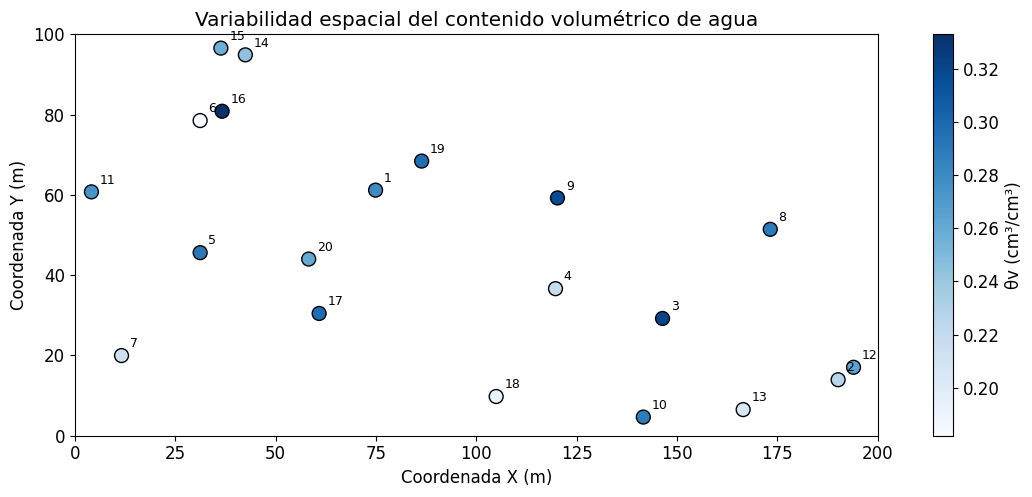

In [13]:
# SOLUCIÓN — Visualizar la distribución espacial de θv
# Gráfico de dispersión de los puntos coloreados por θv

fig, ax = plt.subplots(figsize=(12, 5))
scatter = ax.scatter(datos_campo['X_m'], datos_campo['Y_m'],
                     c=datos_campo['Theta_v'], cmap='Blues',
                     s=100, edgecolors='black')
plt.colorbar(scatter, label='θv (cm³/cm³)')

# Etiquetar cada punto con su número
for _, fila in datos_campo.iterrows():
    ax.annotate(int(fila['Punto']), (fila['X_m'], fila['Y_m']),
                xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.set_xlim(0, 200)
ax.set_ylim(0, 100)
ax.set_aspect('equal')
ax.set_xlabel('Coordenada X (m)')
ax.set_ylabel('Coordenada Y (m)')
ax.set_title('Variabilidad espacial del contenido volumétrico de agua')

plt.tight_layout()
plt.show()

### Pregunta de interpretación

¿Recomendarías un manejo de riego uniforme o diferenciado para este campo? Justifica con el CV y el mapa.

### Respuesta sugerida (manejo uniforme o diferenciado)

El CV es **16,8 %**, apenas sobre el umbral de 15 %, lo que corresponde a **variabilidad moderada**. θv va de 0,182 a 0,333 cm³/cm³: los puntos más secos (5, 17, 12, 6) tienen casi la mitad del agua de los más húmedos (15, 2, 8).

En el mapa no se ve un patrón espacial claro (una zona seca y otra húmeda bien definidas): puntos secos y húmedos aparecen mezclados, lo esperable en datos simulados como aleatorios.

Recomendación: con un CV moderado **conviene considerar un manejo diferenciado**, pero antes de invertir en riego de precisión hay que confirmar que la variabilidad es **estable en el tiempo** y tiene estructura espacial (repetir mediciones en otras fechas, cruzar con textura o con imágenes NDVI). Si la variabilidad es aleatoria y cambia de una fecha a otra, un manejo uniforme ajustado a las zonas más secas, con sensores de monitoreo en puntos representativos, es una opción razonable. Si aparecen zonas persistentes, se justifica sectorizar el riego.

*Nota: con 20 puntos en 2 ha (1 punto cada 1.000 m²) la densidad de muestreo es baja para delimitar zonas de manejo.*

---
## Parte 5: Ejercicio integrador — Lámina de agua en el perfil (30 min)

Dado un perfil de suelo con 3 horizontes, calcular la lámina total de agua aprovechable (mm).

### Datos del perfil

In [14]:
# Perfil de suelo típico de la zona central de Chile (serie Santiago)
perfil = pd.DataFrame({
    'Horizonte': ['Ap', 'Bt', 'C'],
    'Prof_inicial_cm': [0, 30, 70],
    'Prof_final_cm': [30, 70, 100],
    'CC_cm3cm3': [0.34, 0.30, 0.24],
    'PMP_cm3cm3': [0.15, 0.18, 0.14]
})

perfil['Espesor_cm'] = perfil['Prof_final_cm'] - perfil['Prof_inicial_cm']
print('Perfil de suelo:')
perfil

Perfil de suelo:


,Horizonte,Prof_inicial_cm,Prof_final_cm,CC_cm3cm3,PMP_cm3cm3,Espesor_cm
0,Ap,0,30,0.34,0.15,30
1,Bt,30,70,0.30,0.18,40
2,C,70,100,0.24,0.14,30


In [15]:
# SOLUCIÓN — Calcular la lámina de ADT por horizonte y total

perfil['ADT_cm3cm3'] = perfil['CC_cm3cm3'] - perfil['PMP_cm3cm3']
perfil['Lamina_ADT_mm'] = perfil['ADT_cm3cm3'] * perfil['Espesor_cm'] * 10  # mm

lamina_total_mm = perfil['Lamina_ADT_mm'].sum()

# Mostrar resultados por horizonte
print('Lámina de ADT por horizonte:')
display(perfil[['Horizonte', 'Espesor_cm', 'CC_cm3cm3', 'PMP_cm3cm3', 'ADT_cm3cm3', 'Lamina_ADT_mm']].round(2))

print(f'\nLámina total de ADT en el perfil: {lamina_total_mm:.1f} mm')

Lámina de ADT por horizonte:


,Horizonte,Espesor_cm,CC_cm3cm3,PMP_cm3cm3,ADT_cm3cm3,Lamina_ADT_mm
0,Ap,30,0.34,0.15,0.19,57.0
1,Bt,40,0.30,0.18,0.12,48.0
2,C,30,0.24,0.14,0.10,30.0



Lámina total de ADT en el perfil: 135.0 mm


In [16]:
# Validación — lámina total esperada: ~135 mm
if 'Lamina_ADT_mm' in perfil.columns:
    lamina_total = perfil['Lamina_ADT_mm'].sum()
    ok = np.isclose(lamina_total, 135, atol=3)
    print(f'Lámina total: {lamina_total:.1f} mm')
    print('✓ Correcto (≈135 mm esperado)' if ok else '⚠ Revisa los cálculos (esperado ≈135 mm)')
else:
    print('⚠ Calcula Lamina_ADT_mm primero')

Lámina total: 135.0 mm
✓ Correcto (≈135 mm esperado)


In [17]:
# SOLUCIÓN — Calcular AFA y lámina bruta para maíz (p=0.50, Ea=0.90)

p_maiz = 0.50
Ea_goteo = 0.90
afa_total_mm = lamina_total_mm * p_maiz        # lámina neta a reponer
lamina_bruta_mm = afa_total_mm / Ea_goteo      # considera pérdidas del sistema

print(f'AFA total para maíz: {afa_total_mm:.1f} mm')
print(f'Lámina bruta (goteo, Ea=0.90): {lamina_bruta_mm:.1f} mm')
print(f'Interpretación: debemos aplicar {lamina_bruta_mm:.1f} mm de riego cada vez que el suelo alcance el umbral')

# Umbral de riego expresado como lámina remanente en el perfil
print(f'Umbral: regar cuando queden {lamina_total_mm - afa_total_mm:.1f} mm de ADT en el perfil (1 m)')

AFA total para maíz: 67.5 mm
Lámina bruta (goteo, Ea=0.90): 75.0 mm
Interpretación: debemos aplicar 75.0 mm de riego cada vez que el suelo alcance el umbral
Umbral: regar cuando queden 67.5 mm de ADT en el perfil (1 m)


---
## Entregable del Taller 2

Al finalizar, entrega este notebook con todas las celdas completas y ejecutadas.

**Debes incluir:**
1. Tabla de conversión θg → θv para 4 suelos contrastantes ✅
2. Interpretación: ¿Qué suelo tiene más agua volumétrica? ¿Por qué?
3. Gráfico de curvas de retención con CC y PMP identificados ✅
4. Tabla resumen de ADT y AFA por suelo y cultivo ✅
5. Interpretación: frecuencia de riego según tipo de suelo
6. Estadística descriptiva de θv del campo (media, desviación, CV) ✅
7. Mapa de variabilidad espacial ✅
8. Interpretación: ¿manejo uniforme o diferenciado?
9. Lámina total de ADT y AFA para el perfil completo ✅
10. Lámina bruta de riego para maíz con goteo ✅

**Formato de entrega:** Notebook .ipynb descargado de Colab.

---
*Taller 2 (solución) — TAG2027 Relación Suelo Agua Planta | UDLA*